# Task 1 — Preprocess & Explore the Data

**GMF Investments · Week 9**

Load, clean, and explore historical data for **TSLA**, **BND**, and **SPY**
(2015-01-01 → 2026-06-30) to prepare for forecasting and portfolio optimization.

Covers: data extraction, cleaning, EDA (trends, volatility, rolling stats,
outliers), stationarity (ADF), and foundational risk metrics (VaR, Sharpe).

In [1]:
import sys
from pathlib import Path

# Make the project root importable when running from notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config, data_loader as dl, preprocessing as pp, eda

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
config.TICKERS

['TSLA', 'BND', 'SPY']

## 1. Extract Historical Financial Data
Fetched from YFinance and cached to `data/raw/` (only re-downloads if missing).

In [2]:
tidy_raw = dl.get_prices()
print("Shape:", tidy_raw.shape)
print("Date range:", tidy_raw['Date'].min().date(), '->', tidy_raw['Date'].max().date())
print("Rows per ticker:\n", tidy_raw['Ticker'].value_counts())
tidy_raw.head()

Shape: (8664, 8)
Date range: 2015-01-02 -> 2026-06-29
Rows per ticker:
 Ticker
BND     2888
SPY     2888
TSLA    2888
Name: count, dtype: int64


,Date,Ticker,Open,High,Low,Close,Adj Close,Volume
0,2015-01-02,BND,82.430000,82.690002,82.419998,82.650002,59.205639,2218800
1,2015-01-05,BND,82.739998,82.919998,82.699997,82.889999,59.377575,5820100
2,2015-01-06,BND,83.029999,83.379997,83.029999,83.129997,59.549511,3887600
3,2015-01-07,BND,83.139999,83.279999,83.050003,83.180000,59.585304,2433400
4,2015-01-08,BND,83.110001,83.110001,82.970001,83.050003,59.492214,1873400


## 2. Data Cleaning & Understanding
Enforce dtypes, sort chronologically, forward-fill gaps within each ticker,
and confirm no missing values remain.

In [3]:
print("Dtypes before:\n", tidy_raw.dtypes)
print("\nMissing values before clean:\n", tidy_raw.isna().sum())

tidy = pp.clean(tidy_raw)
print("\nMissing values after clean:", int(tidy.isna().sum().sum()))

Dtypes before:
 Date         datetime64[ns]
Ticker               object
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
dtype: object

Missing values before clean:
 Date         0
Ticker       0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Missing values after clean: 0


In [4]:
# Basic statistics per asset (Adj Close)
prices = pp.to_wide(tidy, 'Adj Close')
returns = pp.daily_returns(prices)
prices.describe().round(2)

Ticker,TSLA,BND,SPY
count,2888.00,2888.00,2888.00
mean,148.77,66.28,351.51
std,138.90,4.70,155.44
min,9.58,58.53,154.16
25%,18.39,62.27,223.55
50%,133.44,65.51,312.82
75%,251.93,70.45,432.81
max,489.88,74.58,757.62


## 3. Exploratory Data Analysis
### 3.1 Closing price over time

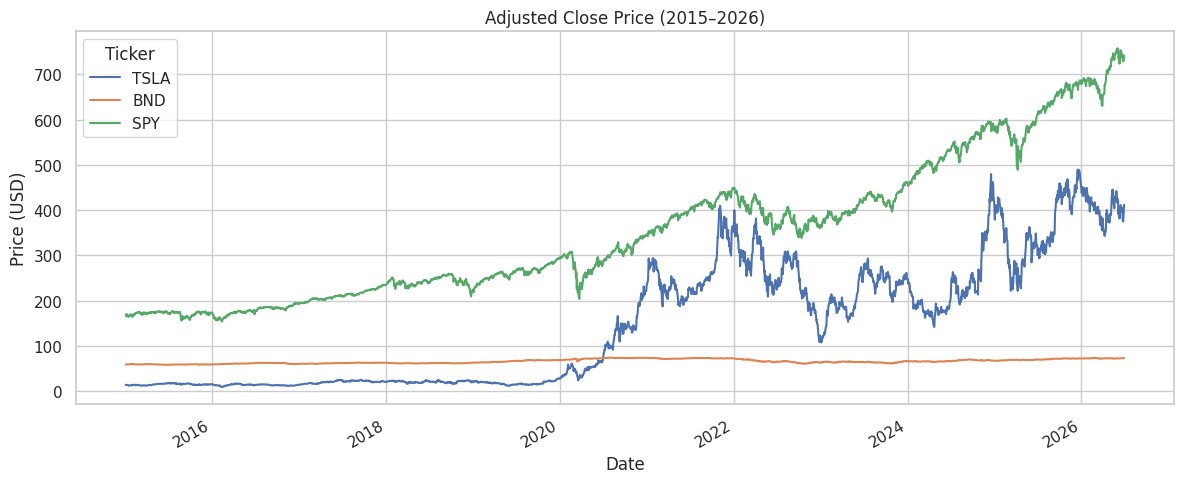

In [5]:
fig, ax = plt.subplots()
prices.plot(ax=ax)
ax.set_title('Adjusted Close Price (2015–2026)')
ax.set_ylabel('Price (USD)')
fig.tight_layout(); fig.savefig(FIG_DIR / '01_prices.png', dpi=120)
plt.show()

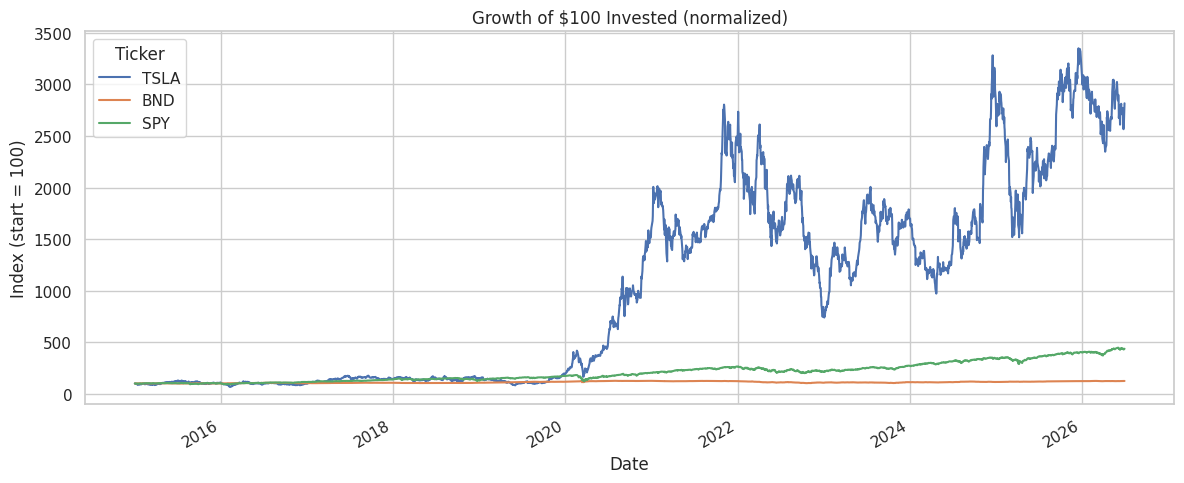

In [6]:
# Normalized to 100 at start — compare relative growth on one scale
norm = prices / prices.iloc[0] * 100
fig, ax = plt.subplots()
norm.plot(ax=ax)
ax.set_title('Growth of $100 Invested (normalized)')
ax.set_ylabel('Index (start = 100)')
fig.tight_layout(); fig.savefig(FIG_DIR / '02_normalized.png', dpi=120)
plt.show()

### 3.2 Daily returns & volatility

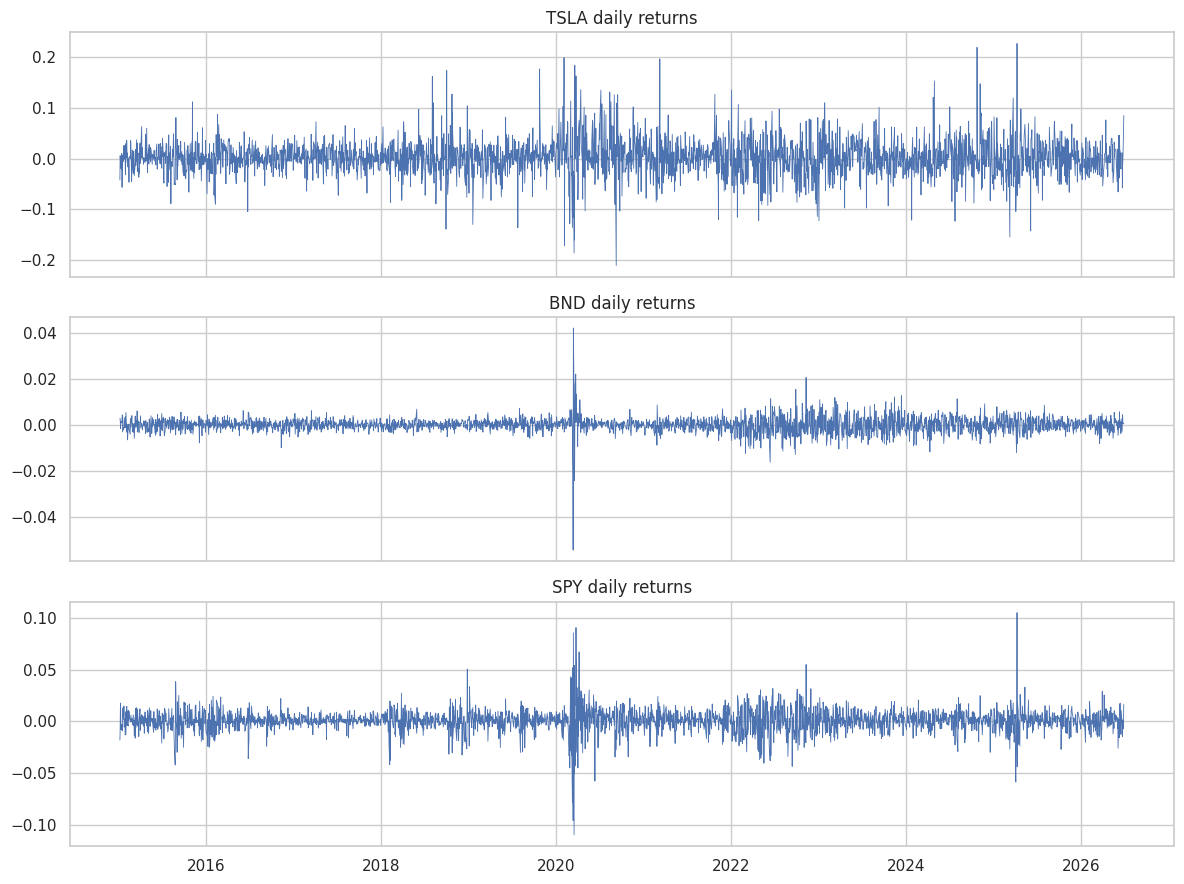

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, col in zip(axes, returns.columns):
    ax.plot(returns.index, returns[col], lw=0.6)
    ax.set_title(f'{col} daily returns')
fig.tight_layout(); fig.savefig(FIG_DIR / '03_daily_returns.png', dpi=120)
plt.show()

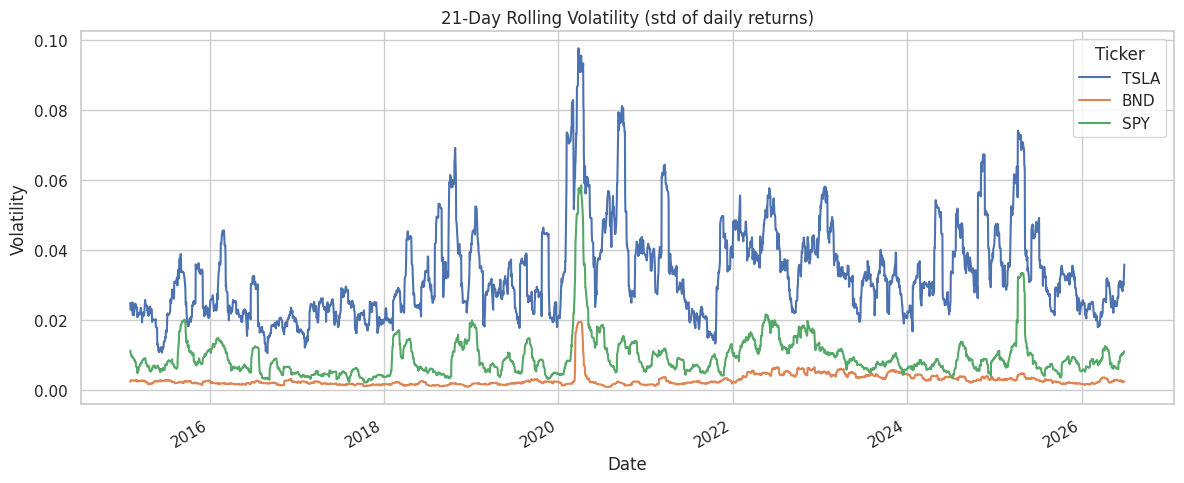

In [8]:
# Rolling 21-day (≈1 month) volatility
roll_vol = pp.rolling_volatility(returns, window=21)
fig, ax = plt.subplots()
roll_vol.plot(ax=ax)
ax.set_title('21-Day Rolling Volatility (std of daily returns)')
ax.set_ylabel('Volatility')
fig.tight_layout(); fig.savefig(FIG_DIR / '04_rolling_vol.png', dpi=120)
plt.show()

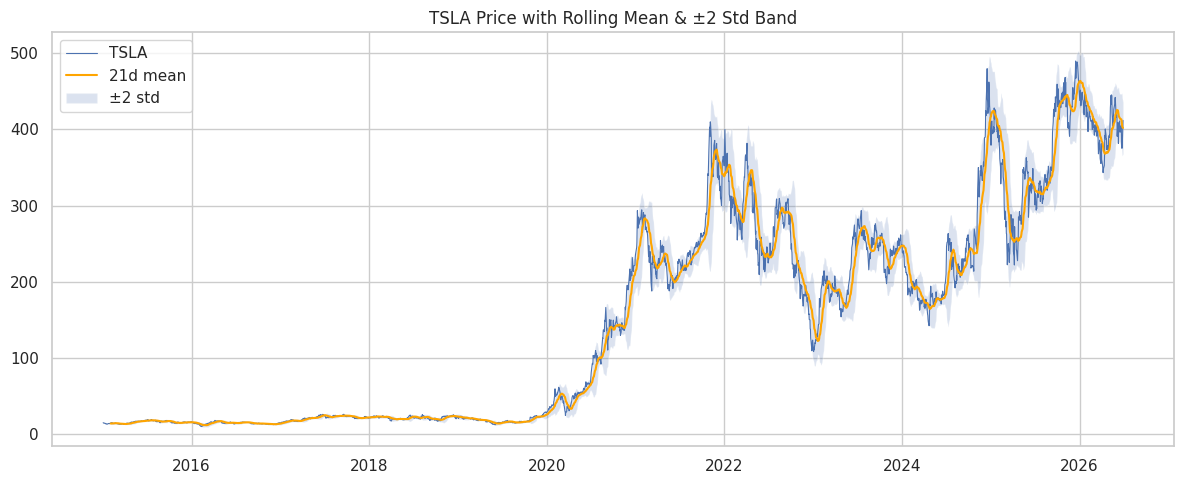

In [9]:
# TSLA rolling mean & std band on price
w = 21
rmean = prices['TSLA'].rolling(w).mean()
rstd = prices['TSLA'].rolling(w).std()
fig, ax = plt.subplots()
ax.plot(prices.index, prices['TSLA'], label='TSLA', lw=0.8)
ax.plot(rmean.index, rmean, label=f'{w}d mean', color='orange')
ax.fill_between(rmean.index, rmean - 2*rstd, rmean + 2*rstd, alpha=0.2, label='±2 std')
ax.set_title('TSLA Price with Rolling Mean & ±2 Std Band')
ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / '05_tsla_bands.png', dpi=120)
plt.show()

### 3.3 Outlier Detection

Days with **|z-score| > 3** on daily returns are statistical anomalies — typically earnings surprises or macro shocks. Below we (a) count them per asset, (b) mark them directly on TSLA's return series, and (c) list the most extreme days. These tail events stress any point forecast and motivate the risk metrics in §5.

Outlier days (|z|>3): {'TSLA': 46, 'BND': 33, 'SPY': 39}


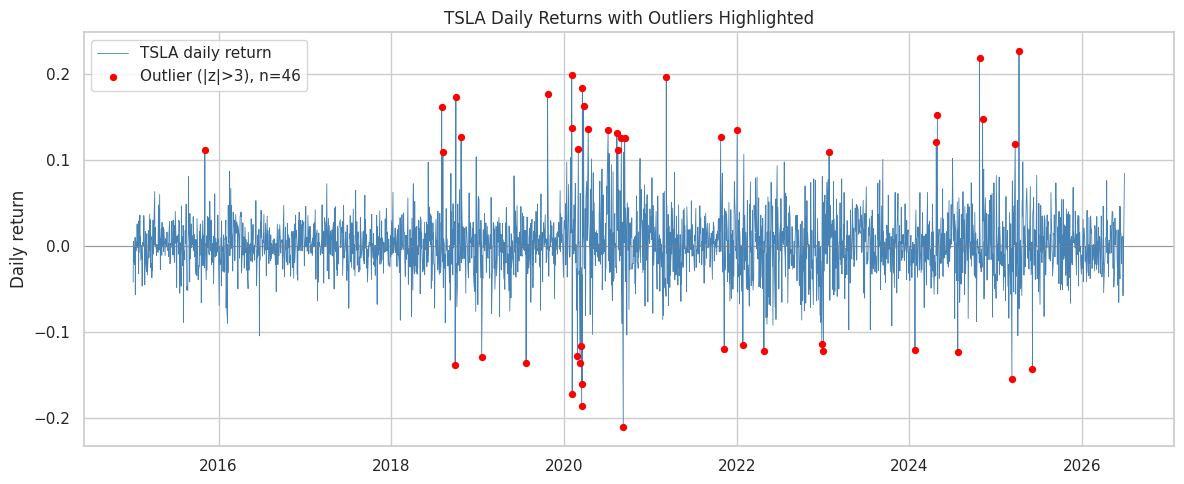


Top 8 most extreme TSLA return days:


,return,zscore,return_%
Date,,,
2025-04-09,0.227,6.250,22.69
2024-10-24,0.219,6.035,21.92
2020-09-08,-0.211,-5.898,-21.06
2020-02-03,0.199,5.473,19.89
2021-03-09,0.196,5.403,19.64
2020-03-16,-0.186,-5.208,-18.58
2020-03-19,0.184,5.055,18.39
2019-10-24,0.177,4.856,17.67


In [10]:
# (a) Count outliers per asset
counts = {c: len(eda.detect_outliers(returns[c], z=3.0)) for c in returns.columns}
print('Outlier days (|z|>3):', counts)

# (b) Mark outliers on TSLA's return series
tsla_out = eda.detect_outliers(returns['TSLA'], z=3.0)
fig, ax = plt.subplots()
ax.plot(returns.index, returns['TSLA'], lw=0.6, color='steelblue', label='TSLA daily return')
ax.scatter(tsla_out.index, tsla_out['return'], color='red', s=18, zorder=3,
           label=f'Outlier (|z|>3), n={len(tsla_out)}')
ax.axhline(0, color='grey', lw=0.5)
ax.set_title('TSLA Daily Returns with Outliers Highlighted')
ax.set_ylabel('Daily return'); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / '10_tsla_outliers.png', dpi=120)
plt.show()

# (c) Most extreme TSLA days
print('\nTop 8 most extreme TSLA return days:')
top = tsla_out.reindex(tsla_out['zscore'].abs().sort_values(ascending=False).index).head(8)
display(top.assign(**{'return_%': (top['return']*100).round(2)}).round(3))

### 3.4 Return Distributions & Tail Risk

Histograms and box plots of daily returns expose fat tails and skew. The dashed line marks each asset's 95% Value at Risk (the 5th percentile of returns) — the same quantity tabulated in §5.

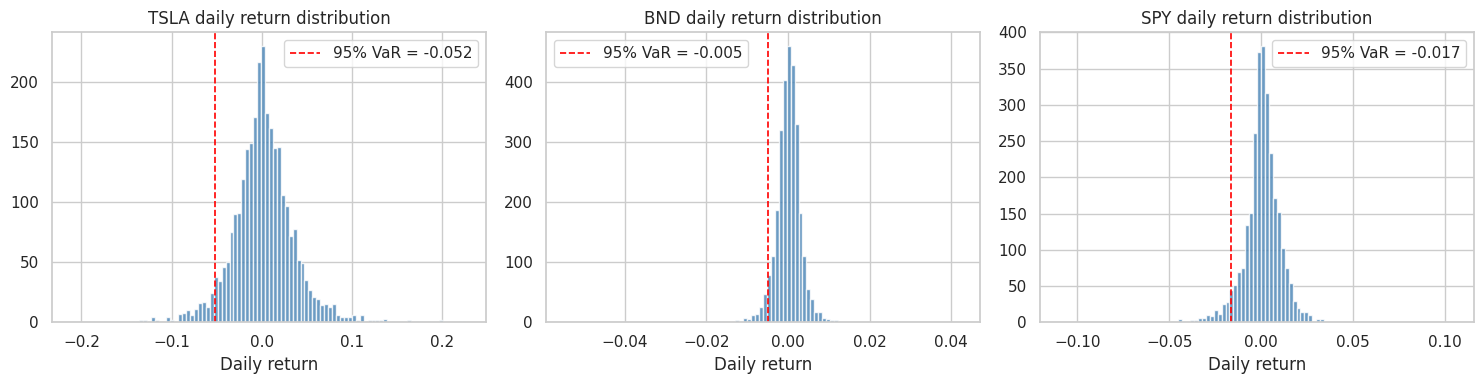

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, returns.columns):
    ax.hist(returns[col].dropna(), bins=100, color='steelblue', alpha=0.8)
    var95 = eda.value_at_risk(returns[col])
    ax.axvline(var95, color='red', ls='--', lw=1.2, label=f'95% VaR = {var95:.3f}')
    ax.set_title(f'{col} daily return distribution')
    ax.set_xlabel('Daily return'); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / '11_return_distributions.png', dpi=120)
plt.show()

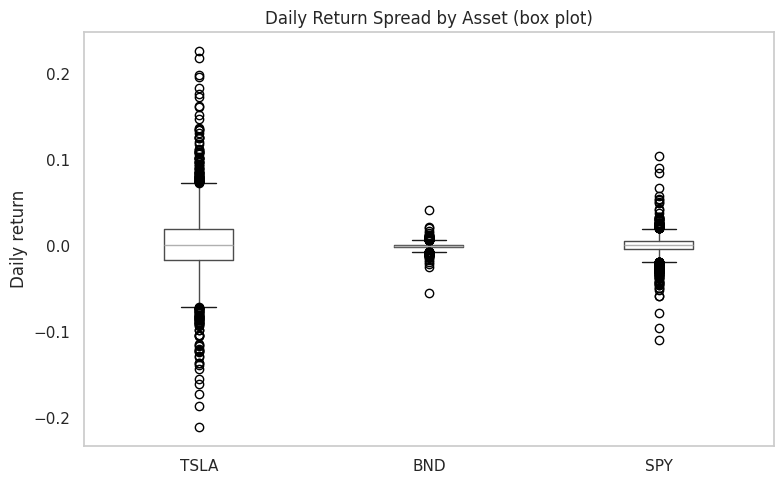

,skew,kurtosis
Ticker,,
TSLA,0.293,4.467
BND,-0.918,36.530
SPY,-0.308,14.025


In [12]:
# Box plot — compares spread/outliers across assets on one scale
fig, ax = plt.subplots(figsize=(8, 5))
returns.boxplot(ax=ax, grid=False)
ax.set_title('Daily Return Spread by Asset (box plot)')
ax.set_ylabel('Daily return')
fig.tight_layout(); fig.savefig(FIG_DIR / '12_return_boxplot.png', dpi=120)
plt.show()

# Skewness & kurtosis quantify the fat tails seen above
shape = pd.DataFrame({
    'skew': returns.skew(),
    'kurtosis': returns.kurtosis(),
}).round(3)
display(shape)

## 4. Stationarity & Trend Analysis (ADF)
Augmented Dickey-Fuller test. **Null = non-stationary (unit root).** p < 0.05 → stationary.
Prices are expected to be non-stationary (require differencing, the `d` in ARIMA);
returns are expected to be stationary.

In [13]:
print('ADF on Adj Close prices:')
display(eda.adf_report(prices)[['adf_statistic', 'p_value', 'stationary']].round(4))
print('\nADF on daily returns:')
display(eda.adf_report(returns)[['adf_statistic', 'p_value', 'stationary']].round(4))

ADF on Adj Close prices:


,adf_statistic,p_value,stationary
series,,,
TSLA,-1.0696,0.7270,False
BND,-1.0479,0.7354,False
SPY,1.3089,0.9967,False



ADF on daily returns:


,adf_statistic,p_value,stationary
series,,,
TSLA,-53.9719,0.0,True
BND,-15.2212,0.0,True
SPY,-17.5722,0.0,True


## 5. Risk Metrics — VaR & Sharpe
95% historical Value at Risk and annualized Sharpe ratio per asset.

In [14]:
risk = eda.risk_summary(returns)
display(risk.round(4))

,annual_return,annual_volatility,sharpe,var_95
TSLA,0.4542,0.5718,0.7595,-0.0517
BND,0.0203,0.0531,0.0047,-0.0048
SPY,0.1443,0.1765,0.7042,-0.0167


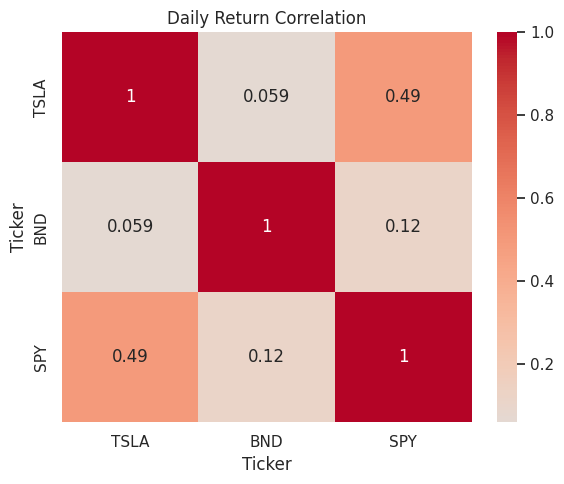

In [15]:
# Correlation of returns — sets up the covariance work in Task 4
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Daily Return Correlation')
fig.tight_layout(); fig.savefig(FIG_DIR / '06_corr.png', dpi=120)
plt.show()

## 6. Save Processed Data
Persist cleaned wide price frame and returns for downstream tasks.

In [16]:
config.PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
prices.to_csv(config.PROCESSED_DIR / 'adj_close_wide.csv')
returns.to_csv(config.PROCESSED_DIR / 'daily_returns.csv')
tidy.to_csv(config.PROCESSED_DIR / 'prices_clean_tidy.csv', index=False)
print('Saved:', [p.name for p in config.PROCESSED_DIR.glob('*.csv')])

Saved: ['model_metrics.csv', 'prices_clean_tidy.csv', 'adj_close_wide.csv', 'daily_returns.csv']


## Key Insights

- **Trend:** TSLA shows strong long-run growth with large drawdowns; SPY grows
  steadily; BND is flat/stable — matching their risk profiles.
- **Volatility:** TSLA's rolling volatility dominates; BND is lowest.
- **Stationarity:** Adj Close prices are non-stationary (p > 0.05) → differencing
  needed for ARIMA. Daily returns are stationary (p < 0.05).
- **Risk:** TSLA has the highest annual return *and* the worst 95% VaR; BND the
  smallest of both. Sharpe ratios quantify the risk-adjusted trade-off.
- **Diversification:** BND is weakly/negatively correlated with equities — useful
  for the Task 4 portfolio.